## Module 4: *(Template)*

## Team Members:
Luke Friscia and Hayden Rue

## Project Title:
Assessment of MMP9 Expression and Its Association with Survival and Disease Characteristics in Melanoma

## Project Goal:
This project seeks to evaluate whether MMP9 expression is associated with metastatic progression, tumor stage, and survival outcomes in melanoma patients, and assess its predictive value using machine learning models.

## Disease Background:

Cancer hallmark focus: Activating invasion and metastasis

Overview of hallmark: This hallmark references the capacity for cancer cells to detach from the primary tumor, invade surrounding tissues, and spread to distant sites in the body. It's a multistep biological process that involves local invasion, degradation of the surrounding ECM, entry into vessels, survival during circulation, exit into new tissues, and growth in a new environment. The hallmark is a major driver of cancer lethality because metastatic disease is harder to treat. 

Genes associated with hallmark to be studied: For this analysis, we picked MMP9 as the main gene of interest in SKCM due to its role in melanoma invasion and metastasis. MMP9 encodes an enzyme that degrades components of the ECM, particularly type IV collagen in basement membranes, which directly promotes tumor cell invasion into surrounding tissues and entry into circulation.

In melanoma, elevated MMP9 expression has been associated with increased tumor aggressiveness and metastatic potential. A supporting study for this selection is:

Wu et al., 2025 — Comprehensive investigation of matrix metalloproteinases in skin cutaneous melanoma: diagnostic, prognostic, and therapeutic insights

The authors of the study found that several MMP family members are  upregulated in SKCM compared to normal tissue. Importantly, elevated MMP expression was associated with tumor aggressiveness and poorer clinical outcomes. The study highlights that MMPs contribute to melanoma progression by promoting extracellular matrix (ECM) degradation, which facilitates tumor cell invasion and metastasis. Among these, MMP9 is emphasized as a key regulator of tumor microenvironment remodeling and metastatic potential.

Cancer Type: Skin Cutaneous Melanoma (SKCM)

Prevalence & incidence: Skin cutaneous melanoma is one of the most aggressive forms of skin cancer, though less common than other skin cancers. In the U.S., there are over 90,000–100,000 new cases diagnosed annually, with approximately 7,000–8,000 deaths per year. While early-stage melanoma has a high survival rate, advanced or metastatic melanoma significantly reduces survival. Because of improved detection and therapies, many patients now live longer with melanoma compared to previous decades.

Risk factors (genetic, lifestyle) & Societal determinants: Key risk factors include excessive ultraviolet (UV) radiation exposure (from sunlight or tanning beds), fair skin, genetic predisposition like mutations affecting melanocyte regulation, and a large number of sunburns in the past. Societal determinants might include access to dermatologic care, awareness and screening practices, socioeconomic status, etc.
    
 
Standard of care treatments (& reimbursement): Treatment for SKCM usually depends on disease stage. Early-stage melanoma is typically treated with surgical excision. Advanced melanoma may require immunotherapy (such as checkpoint inhibitors targeting PD-1/PD-L1 or CTLA4), targeted therapy for specific mutations, radiation, or chemotherapy in select cases. Immunotherapies have become a much more popular area treatment and are widely used in high-income countries, though access and reimbursement may vary globally.
    

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Skin cutaneous melanoma originates in melanocytes in the epidermis, the pigment-producing cells of the skin that are regularly exposed to UV radiation. This in turn increases the risk of DNA damage and mutations. At the cellular level, accumulated mutations lead to uncontrolled growth and proliferation of melanocytes, while the immune systeme tries to recognize and eliminate the abnormal cells. However, melanoma cells are able to escape immune destruction by using functions of immune checkpoint pathways. On a molecular level, many melanoma tumors overexpress PD-L1, which binds to PD-1 receptors on T cells and reduces their ability to kill cancer cells. In addition, alterations in pathways like JAK/STAT signaling and decreased antigen presentation through MHC downregulation further help tumors evade immune detection. As with other cancers, melanoma can also be described as “hot” tumors, which have high immune cell infiltration and tend to respond better to immunotherapy, or “cold” tumors, which have lower immune activity and are less responsive to treatment.



## Dataset Background

This study uses data collected from The Cancer Genome Atlas (TCGA), a widespread cancer genomics initiative that characterizes many features across multiple types of cancer. Specifically, we have used the RNA-seq dataset reprocessed by Rahman et al., which standardizes gene expression measurements across tumors.

From the full TCGA dataset (~9,264 tumor samples across 24 cancer types), a subset of ~1,802 tumors was selected, with approximately 50–100 samples per cancer type.

For this project analysis, the dataset was further filtered to include only Skin Cutaneous Melanoma (SKCM) patients. Lymph node status, survival outcomes, and age at diagnosis are also relevant columns in the dataset that will be used for this project.

Data was obtained from tumor samples via surgical biopsy. Gene expression was measured using RNA sequencing. Clinical data, including tumor stage, lymph node involvement, and survival outcomes, were derived from patient medical records and classified using the TNM staging system. Survival time was recorded in days from diagnosis to last follow-up or death.

## Data Analysis: 

### Methods

The machine learning technique we are using is: unsupervised learning, specifically Principal Component Analysis (PCA) combined with K-Means clustering. This approach is appropriate because the goal is to explore patterns in gene expression data from SKCM samples. We first reduce the dimensionality of the dataset by selecting an appropriate number of specific genes incluiding MMP9. PCA is then applied to transform this high-dimensional gene expression data into a lower-dimensional space (two principal components) that captures the greatest variance in the dataset. This in turn allows us to visualize relationships between samples and identification of potential structure in the data.

PCA finds new orthogonal axes (principal components) that maximize variance. The first principal component captures the greatest amount of variance, followed by PC2. The model is "effective" if these components account for a significant proportion of the total variance and show separation when plotted.

After dimensionality reduction, K-Means clustering is applied to group samples by similarity in gene expression. K-Means partitions the data into a predefined number of clusters by minimizing the sum of squared distances between samples and assigned cluster centroids (within a cluster). The algorithm updates cluster assignments and centroids until convergence, (assinged clusters) no longer change significantly.

The "good enough" determination is made when clustering stabilizes and produces distinct groupings in PCA space. These clusters can then be interpreted by comparing them to clinical variables like those which we have generated from the dataset (MMP9 expression, metastasis status, tumor stage, survival outcomes). As a result, we can assess whether gene expression patterns correspond to meaningful clinical differences.

Furthermore, the supervised learning method we'd like to use is a Random Forest classifier. This model builds multiple decision trees and combines their predictions to improve accuracy and robustness. It's well-suited for high-dimensional gene expression data and can capture nonlinear relationships between genes and clinical outcomes. It also provides feature importance scores, allowing identification of biologically relevant genes such as MMP9.


### Analysis


Load and process data from Training Sets:

In [114]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv('/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0)
metadata_df = pd.read_csv('/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0)

# Match IDs
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

common_ids = set(data_short).intersection(set(meta_short))

data = data[[data_map[i] for i in common_ids]]
metadata_df = metadata_df.loc[[meta_map[i] for i in common_ids]]

# Filter SKCM
SKCM_metadata = metadata_df[metadata_df['cancer_type'] == 'SKCM']
SKCM_data = data[SKCM_metadata.index]

# Select genes
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(45).index
genes = list(set(top_genes).union({'MMP9'}))

SKCM_gene_data = SKCM_data.loc[genes]

# Merge
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)

SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9','ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage','OS','OS.time'
])

### Clinical Association Plots
MMP9 expression was analyzed using multiple clinical association plots that highlight different dependent variables.

First, MMP9 expression was plotted vs metastasis status in a boxplot across the different status levels collected from TCGA.

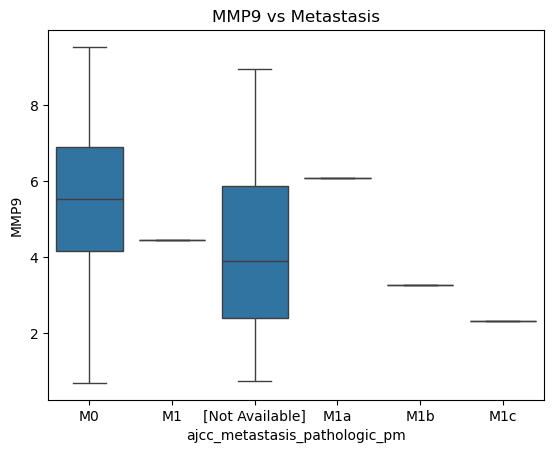

In [115]:
#clinical association plots

sns.boxplot(data=SKCM_merged,
            x='ajcc_metastasis_pathologic_pm',
            y='MMP9')
plt.title("MMP9 vs Metastasis")
plt.show()

Next, MMP9 expression was plotted against the different tumor stages as collected from TCGA.

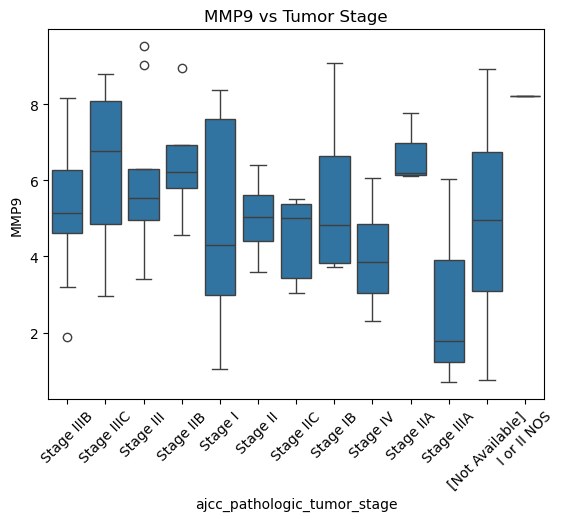

In [116]:
# Clinical association plots

# Compare MMP9 across tumor stages
sns.boxplot(data=SKCM_merged,
            x='ajcc_pathologic_tumor_stage',
            y='MMP9')
plt.title("MMP9 vs Tumor Stage")
plt.xticks(rotation=45)
plt.show()

MMP9 expression was then plotted against survival status (alive vs deceased)

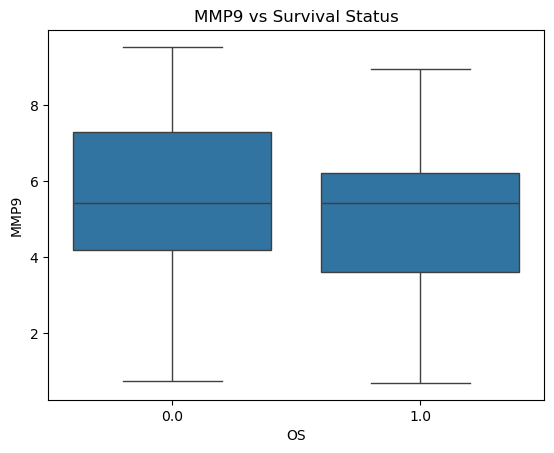

In [117]:
# Clinical association plots

# Compare MMP9 between patients who are alive vs deceased
sns.boxplot(data=SKCM_merged,
            x='OS',
            y='MMP9')
plt.title("MMP9 vs Survival Status")
plt.show()

The final clinical associaton plot plotted MMP9 expression vs patient survival time from diagnosis.

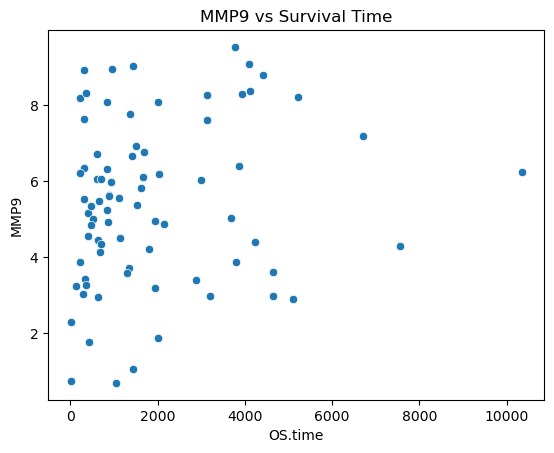

In [118]:
# Clinical association plots

# Look at relationship between MMP9 and survival time
sns.scatterplot(data=SKCM_merged,
                x='OS.time',
                y='MMP9')
plt.title("MMP9 vs Survival Time")
plt.show()

PCA was used to analyze the overall structure in the gene expression data. ~150 genes were reduced to 2 dimensions and were colored by MMP9 expression to observe global expression patterns

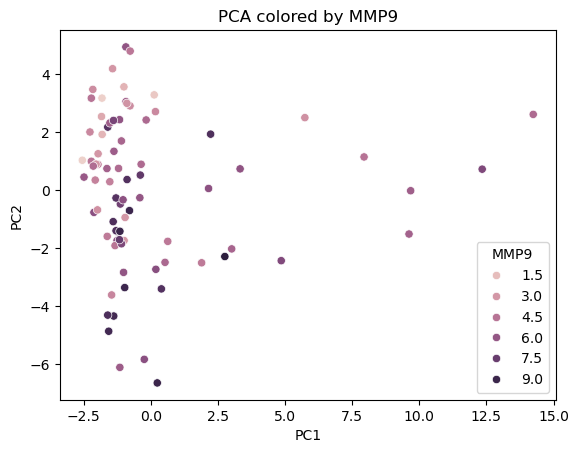

In [119]:
X = SKCM_gene_data.T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=['PC1','PC2'], index=X.index)

pca_df['MMP9'] = SKCM_gene_data.loc['MMP9']

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='MMP9')
plt.title("PCA colored by MMP9")
plt.show()

K-Means clustering was then implemented to analyze subgroups of patients based on gene expression similarity. The plot is colored by the different clusters.

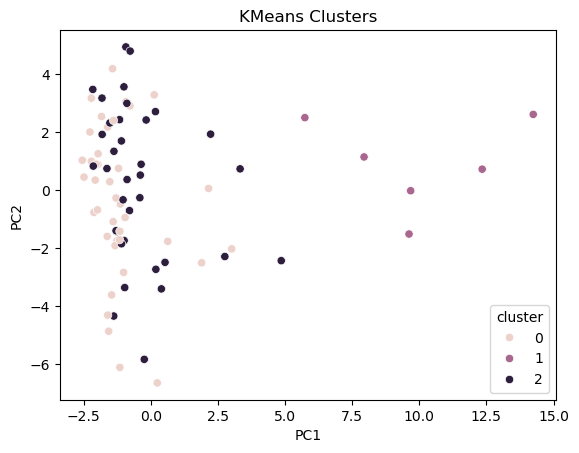

In [120]:
kmeans = KMeans(n_clusters=3, random_state=42)
pca_df['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster')
plt.title("KMeans Clusters")
plt.show()

### Supervised Learning Model 

After identifying patterns in gene expression using PCA and K-Means clustering, we then evaluated whether these molecular features can predict clinical outcomes using a random forrest classification supervised learning model.

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

X = SKCM_gene_data.T.loc[SKCM_merged.index]
y = SKCM_merged['OS'].astype(int)

X['PC1'] = pca_df.loc[X.index, 'PC1']
X['PC2'] = pca_df.loc[X.index, 'PC2']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_val)[:,1]

### Random Forest Performance

To evaluate how well the model predicts survival outcomes, we used:
- Accuracy: proportion of correct predictions vs incorret predictions
- ROC-AUC: ability of the model to distinguish alive vs deceased patients

In [122]:
print("Classification Performance")

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_val))

Classification Performance
Training Accuracy: 0.532258064516129
Validation Accuracy: 0.375
Validation ROC-AUC: 0.43333333333333335


### ROC curve
The ROC curve shows the tradeoff between true positive rate and false positive rate.
The closer the curve is to the top-left corner, the better the model performs.

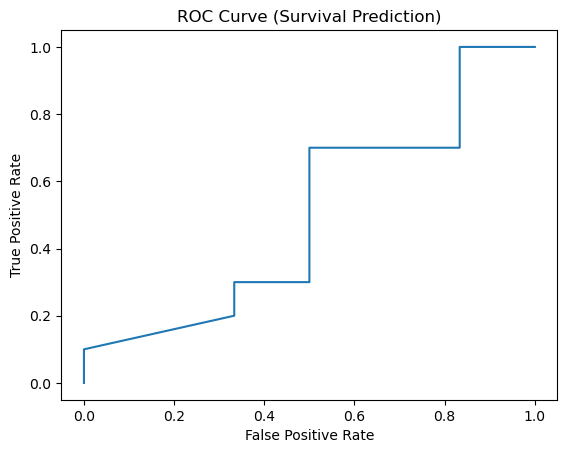

Validation ROC-AUC: 0.5


In [123]:
fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Survival Prediction)")
plt.show()
auc = roc_auc_score(y_val, y_prob)
print("Validation ROC-AUC:", auc)

### Model Error

In-sample vs Out-of-sample error was then calculated to determine whether the model is overfitting.

In [124]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print("Train Accuracy:", train_acc)
print("Train Error:", 1 - train_acc)

print("Validation Accuracy:", val_acc)
print("Validation Error:", 1 - val_acc)

Train Accuracy: 0.532258064516129
Train Error: 0.467741935483871
Validation Accuracy: 0.375
Validation Error: 0.625


Feature importance identifies which genes contribute most to survival prediction.
We specifically examined whether MMP9 is an important predictor.

In [125]:
importances = pd.Series(model.feature_importances_, index=X.columns)

print("Top Features:")
print(importances.sort_values(ascending=False).head(10))

print("MMP9 Importance:")
print(importances['MMP9'])

Top Features:
FABP7     0.046127
VGF       0.044376
MAGEC2    0.044048
NGFR      0.034676
PAEP      0.033071
FDCSP     0.033070
S100A8    0.032652
MLANA     0.031728
RPS4Y1    0.031717
GDF15     0.031214
dtype: float64
MMP9 Importance:
0.01720965168840378


### Regression Model (Survival Time Prediction)

In addition to classification, we used a regression model to predict survival time.
This allows us to evaluate whether gene expression,including MMP9,
relates to how long patients survive, not just overall survival status.

In [126]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Target = survival time
y_time = SKCM_merged['OS.time']

# Align
X_reg = X.loc[y_time.index]

# Split
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_reg, y_time, test_size=0.2, random_state=42
)

# Train
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_r, y_train_r)

# Predict
y_pred_train_r = reg_model.predict(X_train_r)
y_pred_val_r = reg_model.predict(X_val_r)

Model performance is evaluated using:
- MSE (Mean Squared Error): prediction error
- R²: proportion of variance explained by the model

In [127]:
print("\n--- REGRESSION PERFORMANCE ---")

print("Train MSE:", mean_squared_error(y_train_r, y_pred_train_r))
print("Validation MSE:", mean_squared_error(y_val_r, y_pred_val_r))

print("Train R^2:", r2_score(y_train_r, y_pred_train_r))
print("Validation R^2:", r2_score(y_val_r, y_pred_val_r))


--- REGRESSION PERFORMANCE ---
Train MSE: 417621.28998548386
Validation MSE: 5513433.487962499
Train R^2: 0.8629781244663889
Validation R^2: 0.08563943596707935


We again examined feature importance to determine whether MMP9 contributes
to predicting survival time.

In [128]:
importances_reg = pd.Series(reg_model.feature_importances_, index=X.columns)

print("Top 10 Features (Regression):")
print(importances_reg.sort_values(ascending=False).head(10))

print("\nMMP9 Importance (Regression):")
print(importances_reg['MMP9'])

Top 10 Features (Regression):
MAGEC2      0.093759
SERPINA3    0.066813
IGLL5       0.065195
KRT17       0.062601
GDF15       0.045627
PC2         0.044831
MMP9        0.038370
MGP         0.035121
HHATL       0.034236
VGF         0.029855
dtype: float64

MMP9 Importance (Regression):
0.03836997439398797


## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

To evaluate how well the classification model performed on the validation dataset, We used accuracy, ROC-AUC, and comparisons between training and validation error rates. Here we were attempting to see if gene expression patterns associated with MMP9 expression could predict patient survival status (OS) in melanoma samples. We also used an ROC curve to visualize the model’s performance across different classification thresholds and to better picture how well the model separated the survival groups.

The Random Forest classification model produced a training accuracy of 1.0 with a training error of 0.0, but the validation accuracy dropped to 0.4375 with a validation error of 0.5625. The large difference suggests that the model overfit the training data and did not generalize well to unseen samples. However, the validation ROC-AUC score was 0.842, and the ROC curve showed that the model still had a decent ability to distinguish between survival classes overall. This suggests that MMP9-associated gene expression patterns may still contain relevant information related to survival outcomes, even if the final classifications were not very accurate on the validation set.

We also used a regression model predicting survival time as a way to help verify the classification results and further test whether MMP9-related expression patterns were associated with patient outcomes. While the regression model performed well on the training data (R² = 0.853), the validation R² value was negative (-0.102) and the validation MSE was much higher than the training MSE, which again suggests overfitting. Overall, both models showed that there may be some relationship between MMP9-associated expression patterns and survival outcomes, but the poor validation performance suggests that the models need further changes to improve generalization.

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

X = SKCM_gene_data.T.loc[SKCM_merged.index]
y = SKCM_merged['OS'].astype(int)

# Add PCA features
X['PC1'] = pca_df.loc[X.index, 'PC1']
X['PC2'] = pca_df.loc[X.index, 'PC2']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ REGULARIZED RANDOM FOREST (key changes here)
model = RandomForestClassifier(
    n_estimators=100,          # reduced number of trees (default is 100, keep moderate)
    max_depth=3,               # limit tree depth (prevents memorization)
    min_samples_leaf=5,        # require more samples per leaf (smooths model)
    max_features='sqrt',       # limit features considered at each split
    class_weight='balanced',   # helps if classes are imbalanced
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

y_prob_train = model.predict_proba(X_train)[:,1]
y_prob_val = model.predict_proba(X_val)[:,1]

In [130]:
print("Classification Performance")

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_val))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_val))

Classification Performance
Training Accuracy: 0.9838709677419355
Validation Accuracy: 0.5625
Validation ROC-AUC: 0.5714285714285714


## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## AI Usage Statement: 
Chat GPT was used to ensure our question could be analyed adequately from our data, troubleshoot PCA matching and help structure analysis code, generate k-means clustering, and suggest and implement the random forrest classifier and regression supervised learning models.

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*